# San Antonio City Budget Analysis

Exploring the City of San Antonio's adopted budgets from FY 2000 to FY 2026.

**Data source:** PDF budget documents from [sa.gov Budget Archives](https://www.sa.gov/Directory/Departments/OMB/Budget-Archives)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sys
sys.path.insert(0, '..')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '../data/processed/'

## 1. Load Scraped Data

In [2]:
# Combined Budget Summary — revenue and appropriations by category
combined = pd.read_csv(f'{DATA_DIR}combined_budget_summary.csv')
print(f'Combined summary: {len(combined)} rows')
print(f'Fiscal years: {sorted(combined.fiscal_year.unique())}')
print(f'Funds: {combined.fund.unique()}')
combined.head(10)

Combined summary: 1162 rows
Fiscal years: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Funds: ['General Fund' 'Total All Funds']


,section,line_item,amount,fund,fiscal_year
0,balance,BEGINNING BALANCE,116124682.0,General Fund,2008
1,revenue,Property Tax,230833886.0,General Fund,2008
2,revenue,Sales Tax,196242533.0,General Fund,2008
3,revenue,Other Tax,32327386.0,General Fund,2008
4,revenue,Licenses and Permits,5778367.0,General Fund,2008
5,revenue,CPS Energy,253962706.0,General Fund,2008
6,revenue,San Antonio Water System,9425230.0,General Fund,2008
7,revenue,Charges for Services,43908568.0,General Fund,2008
8,revenue,Fines & Forfeits,10956705.0,General Fund,2008
9,revenue,Miscellaneous,12068577.0,General Fund,2008


In [3]:
# All Funds Revenue — granular revenue by source and fund
revenue = pd.read_csv(f'{DATA_DIR}all_funds_revenue.csv')
print(f'All Funds Revenue: {len(revenue)} rows')
print(f'Fiscal years: {sorted(revenue.fiscal_year.unique())}')
print(f'Funds: {revenue.fund.unique()}')
revenue.head(10)

All Funds Revenue: 1497 rows
Fiscal years: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Funds: ['General Fund' 'GENERAL FUND' 'OTHER FUNDS' 'Special Revenue Funds'
 'Enterprise Funds' 'Trust Funds' 'Internal Service Funds'
 'SPECIAL REVENUE FUNDS' 'ENTERPRISE FUNDS' 'TRUST FUNDS'
 'INTERNAL SERVICE FUNDS' 'TRUST FUND']


,fund,line_item,adopted_amount,fiscal_year
0,General Fund,City Sales Tax,196242533.0,2008
1,General Fund,Liquor by the Drink Tax,5200000.0,2008
2,General Fund,Current Property Tax,226095647.0,2008
3,General Fund,Delinquent Property Tax,2693037.0,2008
4,General Fund,Annexation 0,1089723.0,2008
5,General Fund,Penalty and Interest on Delinquent Taxes,2045202.0,2008
6,General Fund,Business and Franchise Tax,27127386.0,2008
7,General Fund,Licenses and Permits,5778367.0,2008
8,General Fund,CPS Energy,228767000.0,2008
9,General Fund,CPS Energy (One Time Revenue) 0 0,15736000.0,2008


In [4]:
# General Fund Department Appropriations
gf_depts = pd.read_csv(f'{DATA_DIR}general_fund_departments.csv')
print(f'General Fund Depts: {len(gf_depts)} rows')
print(f'Fiscal years: {sorted(gf_depts.fiscal_year.unique())}')
gf_depts.head(10)

General Fund Depts: 1143 rows
Fiscal years: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


,department,adopted_amount,fiscal_year
0,Asset Management,1389880.0,2008
1,City Attorney,7082703.0,2008
2,City Auditor,2595255.0,2008
3,City Clerk,1896905.0,2008
4,City Manager,2436531.0,2008
5,Communication & Public Affairs,1026145.0,2008
6,Community Initiatives,23310324.0,2008
7,Contract Services,1390782.0,2008
8,Customer Service & 311 System,3647705.0,2008
9,Downtown Operations,8184155.0,2008


## 2. Total Budget Over Time

In [5]:
# Extract total revenues and appropriations by year
# From the Combined Summary, filter for 'Total All Funds' and key totals
totals_all = combined[
    (combined['fund'] == 'Total All Funds') &
    (combined['line_item'].str.contains('TOTAL APPROPRIATIONS|TOTAL REVENUES|Subtotal Revenues|Subtotal Appropriations', case=False, na=False))
].copy()

totals_gf = combined[
    (combined['fund'] == 'General Fund') &
    (combined['line_item'].str.contains('TOTAL APPROPRIATIONS|TOTAL REVENUES|Subtotal Revenues|Subtotal Appropriations', case=False, na=False))
].copy()

print('Total All Funds lines:')
display(totals_all.pivot_table(index='fiscal_year', columns='line_item', values='amount'))
print('\nGeneral Fund lines:')
display(totals_gf.pivot_table(index='fiscal_year', columns='line_item', values='amount'))

Total All Funds lines:


line_item,Subtotal Appropriations,Subtotal Revenues,TOTAL APPROPRIATIONS,TOTAL REVENUES
fiscal_year,,,,
2008,1.432437e+09,1.535450e+09,1.790167e+09,1.738891e+09
2009,1.543339e+09,1.622498e+09,1.930799e+09,1.855225e+09
2010,1.620223e+09,1.578311e+09,1.852676e+09,1.773216e+09
2011,1.663469e+09,1.628529e+09,1.935719e+09,1.810071e+09
2012,1.645864e+09,1.625451e+09,1.868831e+09,1.789531e+09
2013,1.640963e+09,1.625699e+09,1.872108e+09,1.785636e+09
2014,1.680232e+09,1.704516e+09,1.904138e+09,1.850490e+09
2015,1.780789e+09,1.799075e+09,2.036316e+09,1.984073e+09
2016,1.881659e+09,1.903014e+09,2.141662e+09,2.107917e+09



General Fund lines:


line_item,Subtotal Appropriations,Subtotal Revenues,TOTAL APPROPRIATIONS,TOTAL REVENUES
fiscal_year,,,,
2008,7.604169e+08,8.015672e+08,8.525493e+08,8.273017e+08
2009,8.172857e+08,8.616694e+08,9.299619e+08,8.875022e+08
2010,8.609908e+08,8.161937e+08,8.870772e+08,8.441490e+08
2011,9.055761e+08,8.359630e+08,9.268459e+08,8.595259e+08
2012,9.293136e+08,8.687081e+08,9.481756e+08,8.952955e+08
2013,9.612469e+08,8.924788e+08,9.796168e+08,9.181501e+08
2014,9.788035e+08,9.313768e+08,9.882571e+08,9.616011e+08
2015,1.040299e+09,9.971645e+08,1.048305e+09,1.031900e+09
2016,1.086923e+09,1.059327e+09,1.098678e+09,1.096299e+09


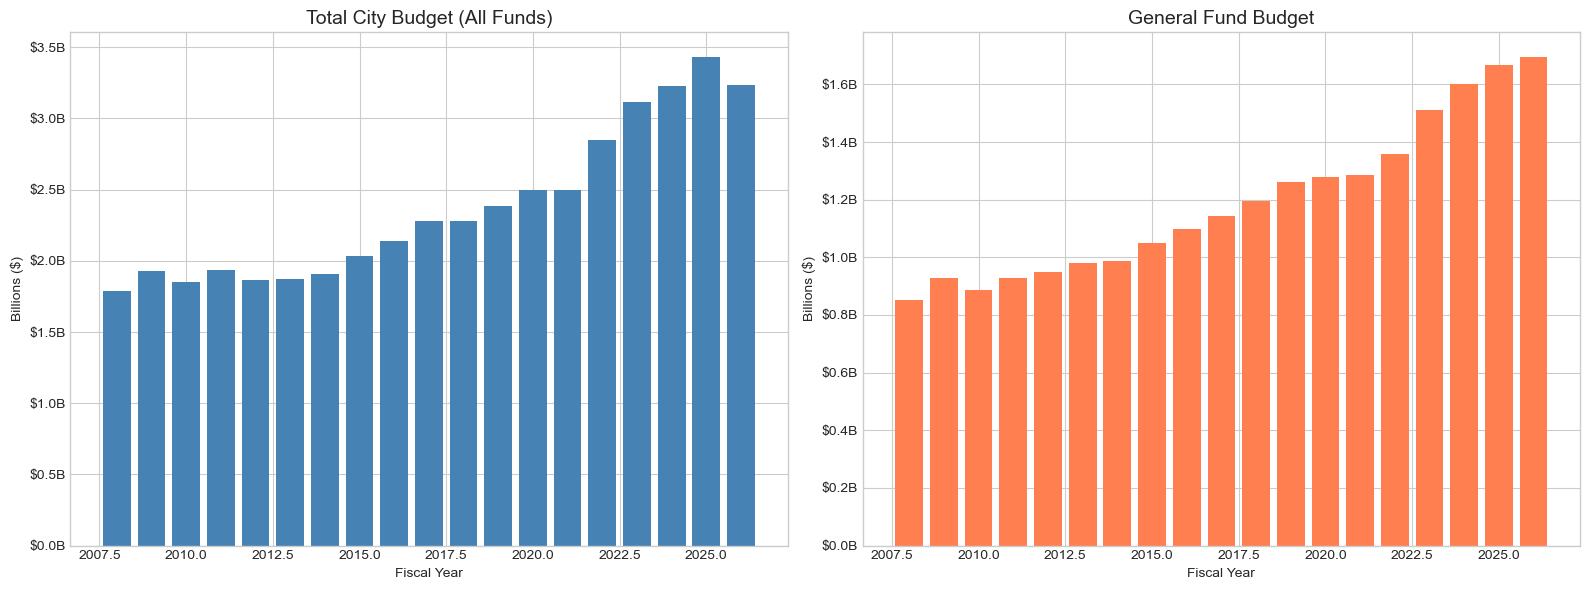

In [6]:
# Plot Total Budget Over Time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All Funds
total_approp = totals_all[totals_all['line_item'].str.contains('TOTAL APPROPRIATIONS', case=False)]
total_approp = total_approp.sort_values('fiscal_year')
axes[0].bar(total_approp['fiscal_year'], total_approp['amount'] / 1e9, color='steelblue')
axes[0].set_title('Total City Budget (All Funds)', fontsize=14)
axes[0].set_xlabel('Fiscal Year')
axes[0].set_ylabel('Billions ($)')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fB'))

# General Fund
gf_approp = totals_gf[totals_gf['line_item'].str.contains('TOTAL APPROPRIATIONS|Subtotal Appropriations', case=False)]
gf_approp = gf_approp.sort_values('fiscal_year')
axes[1].bar(gf_approp['fiscal_year'], gf_approp['amount'] / 1e9, color='coral')
axes[1].set_title('General Fund Budget', fontsize=14)
axes[1].set_xlabel('Fiscal Year')
axes[1].set_ylabel('Billions ($)')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fB'))

plt.tight_layout()
plt.savefig('../figures/total_budget_over_time.png', bbox_inches='tight')
plt.show()

## 3. Revenue Composition

In [7]:
# General Fund revenue breakdown from the combined summary
gf_revenue = combined[
    (combined['fund'] == 'General Fund') &
    (combined['section'] == 'revenue') &
    (~combined['line_item'].str.contains('Subtotal|TOTAL|Transfer', case=False, na=False))
].copy()

# Normalize line_item names that changed convention across years
gf_revenue['line_item'] = gf_revenue['line_item'].replace({
    'Fines and Forfeits': 'Fines & Forfeits',
})

# Pivot to get revenue sources over time
rev_pivot = gf_revenue.pivot_table(
    index='fiscal_year', columns='line_item', values='amount', aggfunc='first'
)

print(f'Revenue categories: {list(rev_pivot.columns)}')
rev_pivot

Revenue categories: ['CPS Energy', 'Charges for Services', 'Delinquent Property Tax', 'Fines & Forfeits', 'Licenses and Permits', 'Miscellaneous', 'Other Tax', 'Property Tax', 'Sales Tax', 'San Antonio Water System']


line_item,CPS Energy,Charges for Services,Delinquent Property Tax,Fines & Forfeits,Licenses and Permits,Miscellaneous,Other Tax,Property Tax,Sales Tax,San Antonio Water System
fiscal_year,,,,,,,,,,
2008,253962706.0,43908568.0,NaN,10956705.0,5778367.0,12068577.0,32327386.0,230833886.0,196242533.0,9425230.0
2009,288861091.0,41673749.0,NaN,12166379.0,6129118.0,11659658.0,32656627.0,249872945.0,202809519.0,9880665.0
2010,251053000.0,43372206.0,NaN,14234582.0,5647275.0,9390135.0,35389162.0,249172145.0,189565423.0,10155356.0
2011,275758786.0,43940287.0,4807790.0,14794483.0,5651259.0,10488855.0,35309277.0,239738583.0,188070529.0,9868940.0
2015,315962248.0,63574564.0,4842353.0,13449057.0,7986740.0,10347312.0,37691057.0,268477764.0,253371067.0,13373971.0
2016,335933940.0,59397276.0,4857474.0,12302770.0,7859992.0,10325645.0,38396970.0,293694785.0,274646415.0,13896079.0
2017,342747851.0,60625858.0,4871801.0,12402492.0,8809947.0,11538529.0,39877998.0,317504778.0,275848790.0,14374768.0
2018,352469884.0,63381125.0,4871801.0,11950000.0,9055174.0,13941288.0,39200024.0,342164372.0,285213407.0,16387483.0
2019,363043981.0,67276064.0,2832210.0,11729139.0,9287323.0,19067934.0,37263953.0,361881034.0,295298361.0,18267512.0


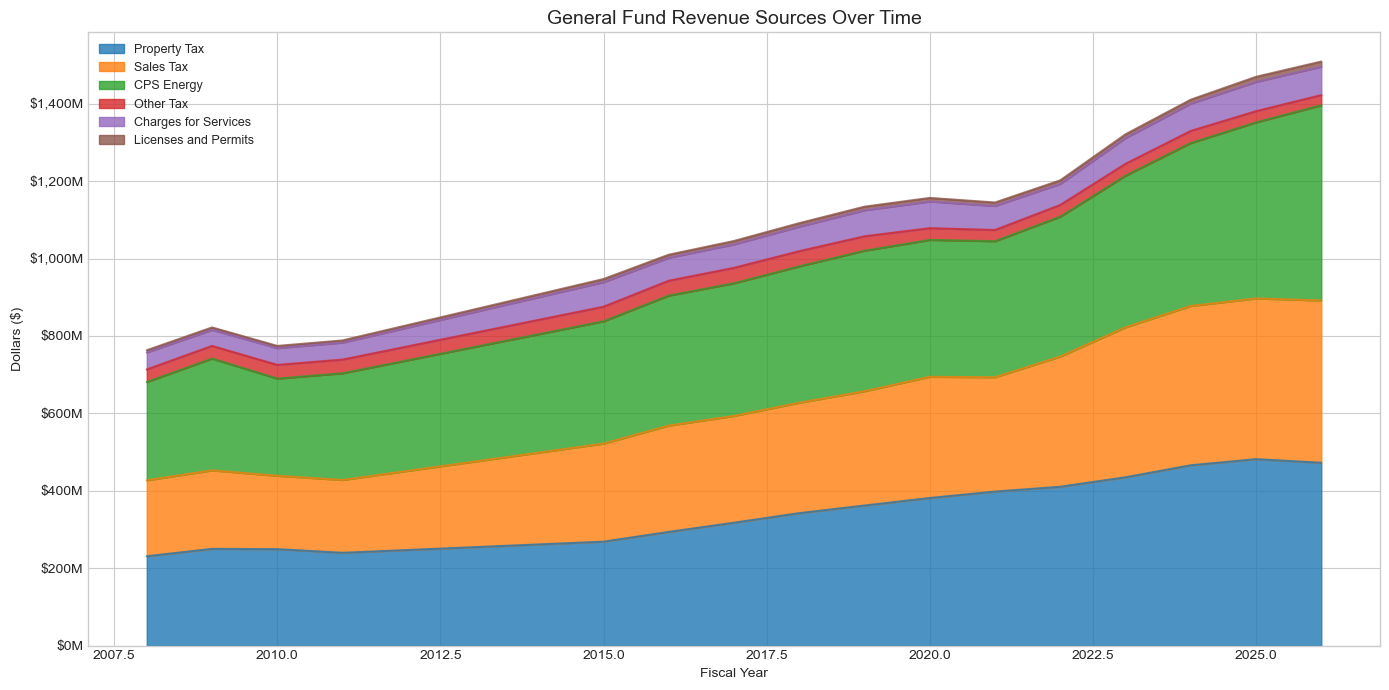

In [8]:
# Stacked area chart of major revenue sources
major_rev_cols = ['Property Tax', 'Sales Tax', 'CPS Energy', 'Other Tax',
                  'Charges for Services', 'Licenses and Permits']
# Filter to columns that exist
avail_cols = [c for c in major_rev_cols if c in rev_pivot.columns]

fig, ax = plt.subplots(figsize=(14, 7))
rev_pivot[avail_cols].dropna(how='all').plot.area(ax=ax, alpha=0.8)
ax.set_title('General Fund Revenue Sources Over Time', fontsize=14)
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Dollars ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:,.0f}M'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/revenue_composition.png', bbox_inches='tight')
plt.show()

## 4. Spending by Category (All Funds)

In [9]:
# Appropriations by category from Total All Funds
spending = combined[
    (combined['fund'] == 'Total All Funds') &
    (combined['section'] == 'appropriation') &
    (~combined['line_item'].str.contains('Subtotal|TOTAL|Transfer|Reserve|GROSS|Financial', case=False, na=False))
].copy()

# Normalize line_item names that changed convention across years
spending['line_item'] = spending['line_item'].replace({
    'Health and Human Services': 'Health & Human Services',
    'Parks and Recreation': 'Parks & Recreation',
    'Streets and Infrastructure': 'Streets & Infrastructure',
    'Economic Development & Development Svcs': 'Economic Development',
})

spend_pivot = spending.pivot_table(
    index='fiscal_year', columns='line_item', values='amount', aggfunc='first'
)

print(f'Spending categories: {list(spend_pivot.columns)}')
spend_pivot

Spending categories: ['Administrative & Operational Excellence', 'Convention, Tourism & Culture', 'Debt Service', 'Economic Development', 'Environmental', 'Health & Human Services', 'Neighborhood Services', 'Parks & Recreation', 'Public Safety', 'Streets & Infrastructure']


line_item,Administrative & Operational Excellence,"Convention, Tourism & Culture",Debt Service,Economic Development,Environmental,Health & Human Services,Neighborhood Services,Parks & Recreation,Public Safety,Streets & Infrastructure
fiscal_year,,,,,,,,,,
2008,69808786.0,63371102.0,193023570.0,59632530.0,81131845.0,239851164.0,11476088.0,53654891.0,5.799905e+08,80496498.0
2009,86526994.0,65049409.0,213554596.0,61290707.0,96709644.0,241486681.0,12056209.0,53349903.0,6.244331e+08,88881407.0
2010,76362703.0,65216728.0,259796277.0,75961078.0,80463031.0,249021207.0,16097335.0,48633357.0,6.368132e+08,111857567.0
2011,69182366.0,63555023.0,248888907.0,91833602.0,110535414.0,232364491.0,21714348.0,62266913.0,6.367826e+08,126345470.0
2013,69651655.0,73435942.0,236933976.0,85285405.0,90364312.0,209212960.0,30035699.0,61460122.0,6.706863e+08,113897029.0
2014,64119340.0,75040498.0,239476173.0,115163240.0,95950037.0,211340936.0,44896799.0,52496020.0,6.755681e+08,106181374.0
2015,70177042.0,71568208.0,254939795.0,117134867.0,101340233.0,228522632.0,52668074.0,53374005.0,7.098760e+08,121188354.0
2016,69031899.0,75155884.0,285486806.0,121335143.0,105768949.0,241906729.0,49711819.0,56099729.0,7.500985e+08,127063684.0
2017,80910110.0,106551884.0,266243843.0,127475405.0,111986309.0,252154848.0,54380138.0,58824315.0,7.753264e+08,132889517.0


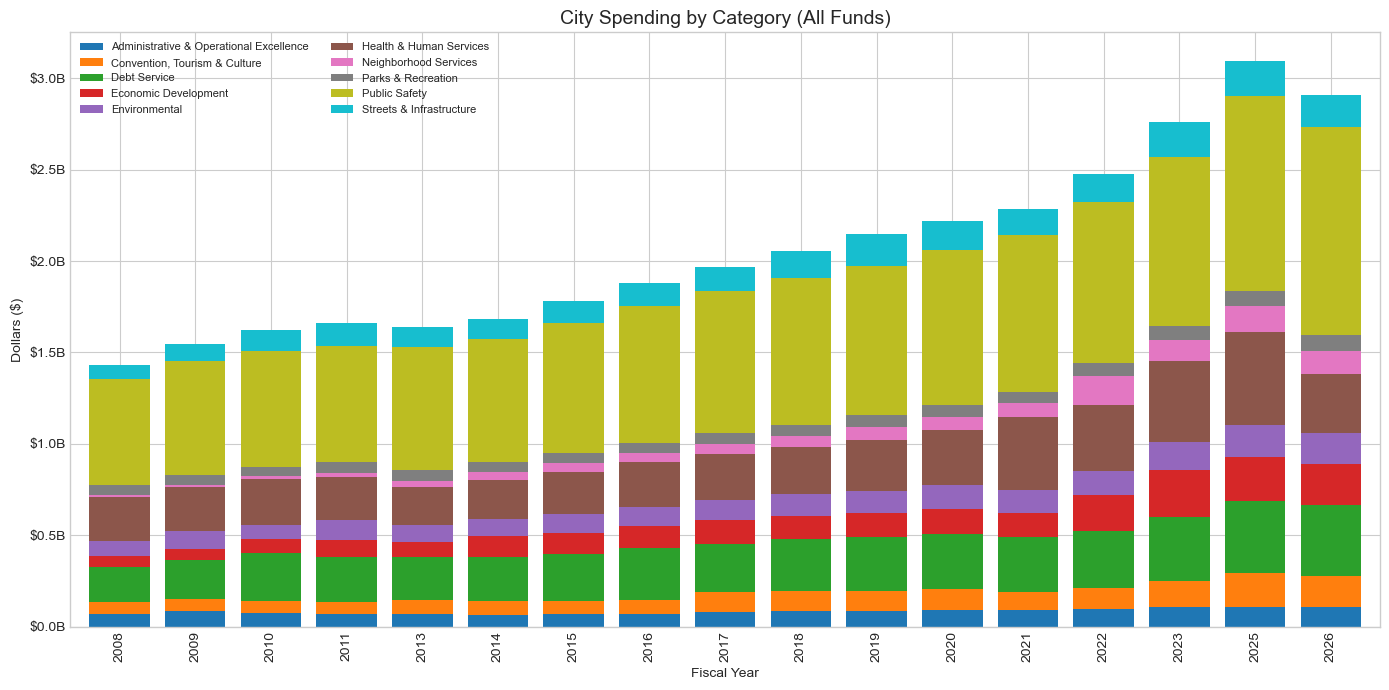

In [10]:
# Stacked bar chart of spending categories
fig, ax = plt.subplots(figsize=(14, 7))
spend_pivot.dropna(how='all').plot.bar(stacked=True, ax=ax, width=0.8)
ax.set_title('City Spending by Category (All Funds)', fontsize=14)
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Dollars ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e9:,.1f}B'))
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../figures/spending_by_category.png', bbox_inches='tight')
plt.show()

## 5. General Fund Department Spending

In [11]:
# Clean up department names and filter to actual departments
depts = gf_depts[
    ~gf_depts['department'].str.contains(
        'TOTAL|AVAILABLE|ENDING|Reserve|Financial|NET|GROSS|Balance',
        case=False, na=False
    )
].copy()

# Show top departments by latest fiscal year
latest_fy = depts['fiscal_year'].max()
top_depts = depts[depts['fiscal_year'] == latest_fy].nlargest(15, 'adopted_amount')
print(f'Top 15 departments by spending in FY {latest_fy}:')
top_depts[['department', 'adopted_amount']].reset_index(drop=True)

Top 15 departments by spending in FY 2026:


,department,adopted_amount
0,City Auditor,2.135464e+11
1,Arrestee Processing Center,1.958288e+11
2,Municipal Elections,5.086848e+10
3,Center City Development & Operations,1.771755e+10
4,Absolute Exemptions,1.642496e+10
5,Health,1.398748e+10
6,Over-65 Exemptions,9.005842e+09
7,Communications & Engagement,4.838856e+09
8,Fire,1.632467e+09
9,Economic Development,9.987386e+08


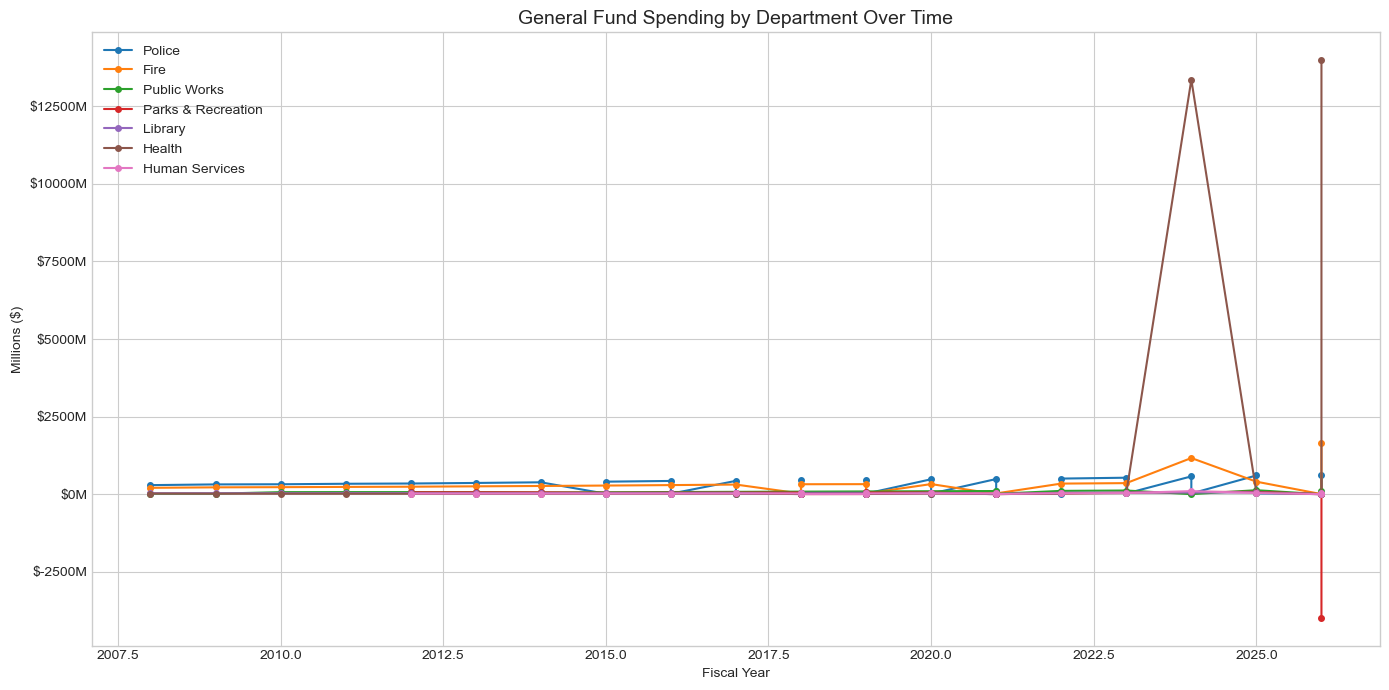

In [12]:
# Track key departments over time
key_depts = ['Police', 'Fire', 'Public Works', 'Parks & Recreation',
             'Library', 'Health', 'Human Services']

fig, ax = plt.subplots(figsize=(14, 7))
for dept in key_depts:
    dept_data = depts[depts['department'].str.contains(dept, case=False, na=False)]
    dept_data = dept_data.sort_values('fiscal_year')
    if not dept_data.empty:
        ax.plot(dept_data['fiscal_year'], dept_data['adopted_amount'] / 1e6,
                marker='o', markersize=4, label=dept)

ax.set_title('General Fund Spending by Department Over Time', fontsize=14)
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Millions ($)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fM'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../figures/dept_spending_over_time.png', bbox_inches='tight')
plt.show()

## 6. Data Quality Check

In [13]:
# Check which fiscal years we have data for in each dataset
print('Combined Summary FY coverage:')
print(sorted(combined['fiscal_year'].unique()))

print('\nAll Funds Revenue FY coverage:')
print(sorted(revenue['fiscal_year'].unique()))

print('\nGeneral Fund Depts FY coverage:')
print(sorted(gf_depts['fiscal_year'].unique()))

# Cross-check: does the GF total from combined match GF depts total?
print('\nCross-check General Fund totals:')
for fy in sorted(combined['fiscal_year'].unique()):
    comb_total = combined[
        (combined['fiscal_year'] == fy) &
        (combined['fund'] == 'General Fund') &
        (combined['line_item'].str.contains('Subtotal Appropriations', case=False))
    ]['amount'].sum()
    dept_total = gf_depts[
        (gf_depts['fiscal_year'] == fy) &
        (gf_depts['department'].str.contains('TOTAL APPROPRIATIONS', case=False))
    ]['adopted_amount'].sum()
    if comb_total > 0 or dept_total > 0:
        match = 'OK' if abs(comb_total - dept_total) < 1000 else 'MISMATCH'
        print(f'  FY {fy}: Combined=${comb_total/1e6:,.0f}M  Depts=${dept_total/1e6:,.0f}M  [{match}]')

Combined Summary FY coverage:
[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

All Funds Revenue FY coverage:
[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

General Fund Depts FY coverage:
[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

Cross-check General Fund totals:
  FY 2008: Combined=$760M  Depts=$853M  [MISMATCH]
  FY 2009: Combined=$817M  Depts=$67M  [MISMATCH]
  FY 2010: Combined=$861M  Depts=$887M  [MISMATCH]
  FY 2011: Combined=$906M  Depts=$927M  [MISMATCH]
  FY 2012: Combined=$929M  Depts=$948M  [MISMATCH]
  FY 2013: Combined=$961M  Depts=$980M  [MISMATCH]
  FY 2014: Combined=$979M  Depts=$988M  [MISMATCH]
  FY 2015: Combined=$1,040M  Depts=$1,048M  [MISMATCH]
  FY 2016: Combined=$1,087M  Depts=$1,099M  [MISMATCH]
  FY 2017: Combined=$1,130M  Depts=$1,143M  [MISMATCH]
  FY 